# 11 · Detecting tropical forest clearing with NISAR

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bullocke/nice-sar/blob/main/notebooks/11_disturbance_detection.ipynb)

Between November 2025 and September 2026, hundreds of hectares of rainforest were cleared along a deforestation frontier in Caquetá, Colombia. NISAR imaged the area every 12 days. This notebook asks a simple question: **what does a forest clearing look like to an L-band radar, and how early can we see it?**

**What you will learn**

- HV backscatter drops by 1 to 2 dB when forest becomes pasture.
- Interferometric coherence first **dips** when trees are felled, then **rises** and stays high once the land is open.
- A single coherence pair is noisy, but comparing an area with its **own history** and with **nearby forest** makes clearings stand out by 13 to 18 standard deviations.

> **Provisional data.** NISAR products used here are PROVISIONAL: calibrated but only partly validated. Numbers may shift once validated products are released.

**Runtime:** about 1 minute with the demo bundle (no login needed).

In [1]:
# Colab only: install nice-sar (about 1 minute)
import sys

if "google.colab" in sys.modules:
    %pip install -q "fsspec<=2025.3.0" "s3fs<=2025.3.0" "nice-sar @ git+https://github.com/bullocke/nice-sar.git@main"

In [2]:
import logging
import warnings

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap
from scipy import ndimage

from nice_sar.analysis import disturbance as dist
from nice_sar.datasets import load_caqueta_demo
from nice_sar.viz.style import CMAPS, COLORS, add_colorbar, add_scalebar, image_axes, use_nice_style

logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s", force=True)
logging.getLogger("PIL").setLevel(logging.WARNING)
log = logging.getLogger("nb11")
warnings.filterwarnings("ignore", message="(All-NaN slice|Mean of empty slice)")
use_nice_style()
%config InlineBackend.figure_formats = ["jpeg"]
%config InlineBackend.print_figure_kwargs = {"bbox_inches": "tight", "pil_kwargs": {"quality": 90}}

## 1. Load the data

The demo bundle holds everything on one 20 m grid covering 22 × 18 km: 11 dates of HV backscatter, 21 pairs of HH coherence at 80 m and 20 m posting, [RADD](https://www.wur.nl/en/research-results/chair-groups/environmental-sciences/laboratory-of-geo-information-science-and-remote-sensing/research/sensing-measuring/radd-forest-disturbance-alert.htm) deforestation alerts, cloud-free Sentinel-2 images, and clearing outlines drawn from Sentinel-2. It was cut from full NISAR frames with `nice_sar.io.subset.subset_product`; the last section shows how to stream the same data yourself.

In [3]:
demo = load_caqueta_demo()
H, W = demo.shape
PX = demo.pixel_m
forest = demo.stable_forest()  # RADD forest, never alerted, >= 100 m from any alert

log.info("Grid %d x %d at %.0f m; HV dates %s to %s", H, W, PX, demo.hv_dates[0], demo.hv_dates[-1])
log.info("Coherence pairs: %d, from %s to %s", len(demo.pair_ref), demo.pair_ref[0], demo.pair_sec[-1])


def rgb_on(date: str) -> np.ndarray:
    """Sentinel-2 true colour on a given date."""
    return demo.s2_rgb[list(demo.s2_rgb_dates).index(np.datetime64(date))]


def pair_label(i: int) -> str:
    fmt = lambda d: d.astype(object).strftime("%-d %b")  # noqa: E731
    return f"{fmt(demo.pair_ref[i])}–{fmt(demo.pair_sec[i])}"


def outline(ax, mask: np.ndarray, color: str = COLORS["outline"], lw: float = 1.5) -> None:
    ax.contour(mask.astype(float), levels=[0.5], colors=color, linewidths=lw)

INFO: Caquetá demo: 11 HV dates, 21 coherence pairs, 40 cases


INFO: Grid 885 x 1112 at 20 m; HV dates 2025-12-09 to 2026-08-30


INFO: Coherence pairs: 21, from 2025-11-03 to 2026-09-11


## 2. The study area

Before and after images from Sentinel-2 show the scale of clearing. Yellow outlines mark the eight clearings we follow below. RADD, an operational alert system based on Sentinel-1 C-band radar, flagged most of them, often weeks after the fact.

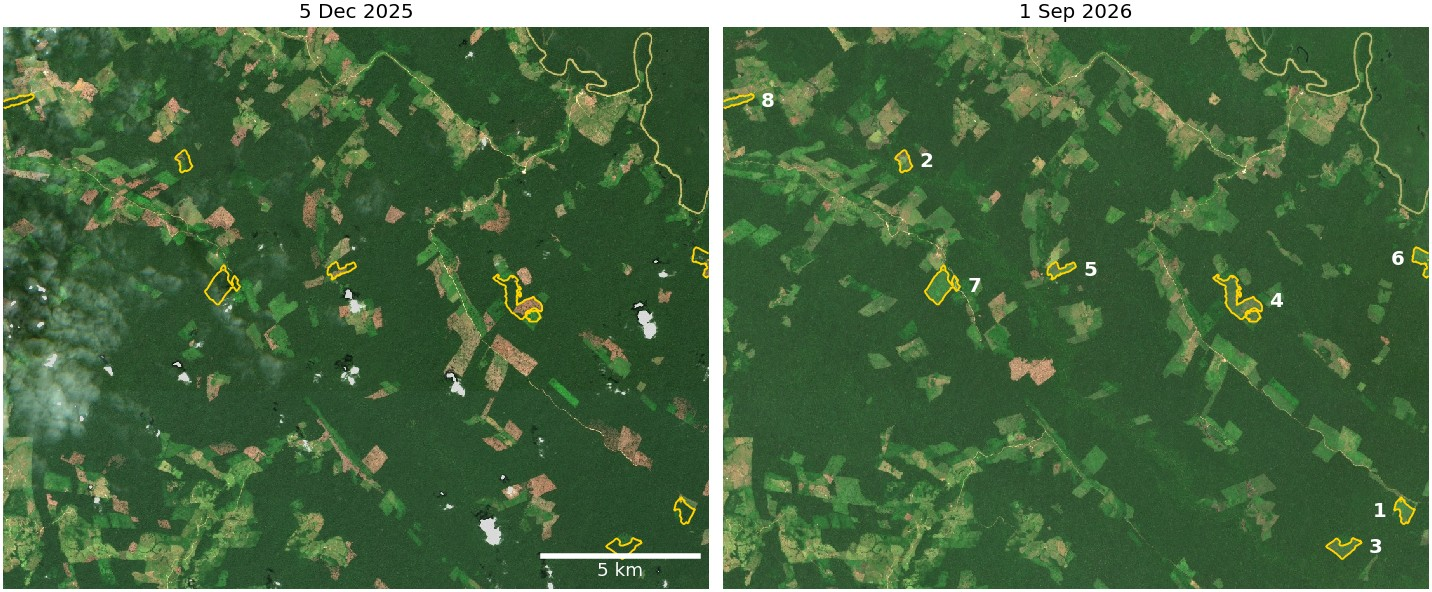

In [4]:
clearings = demo.cases_in("forest_clearing")
cleared_mask = np.zeros(demo.shape, bool)
for c in clearings:
    cleared_mask |= c.mask(demo.shape)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.6))
for ax, date, title in zip(axes, ["2025-12-05", "2026-09-01"], ["5 Dec 2025", "1 Sep 2026"]):
    ax.imshow(rgb_on(date))
    outline(ax, cleared_mask, lw=1.2)
    image_axes(ax, title)
add_scalebar(axes[0], PX)
for c in clearings:
    right = c.cols.max() + 40 < W
    x = c.cols.max() + 12 if right else c.cols.min() - 12
    axes[1].text(x, c.rows.mean(), c.case_id.split("_")[-1], color="white", fontsize=13, va="center", ha="left" if right else "right", fontweight="bold")
plt.show()

## 3. HV backscatter drops after clearing

Cross-polarized (HV) backscatter comes mostly from volume scattering in the canopy, so forest is bright and pasture is dark. Remove the canopy and HV falls, from about −10 dB in forest toward about −12 dB in older pasture. Compare the first and last HV images of the season: the eight clearings (yellow) turn from forest-bright to pasture-dark. Speckle is reduced with a 3 × 3 boxcar filter in linear power (`boxcar_db`).

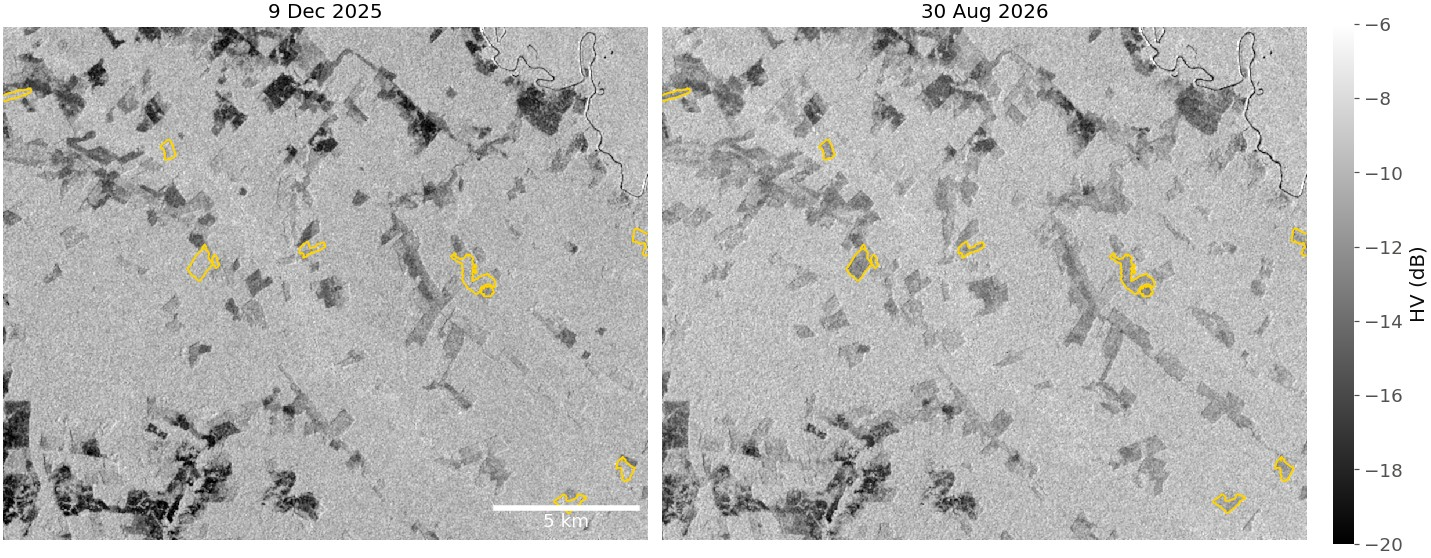

In [5]:
smooth = dist.boxcar_db(demo.hv, 3)
fig, axes = plt.subplots(1, 2, figsize=(13, 5.6))
for ax, t in zip(axes, [0, len(demo.hv_dates) - 1]):
    im = ax.imshow(smooth[t], **CMAPS["hv"])
    outline(ax, cleared_mask, lw=1.2)
    image_axes(ax, demo.hv_dates[t].astype(object).strftime("%-d %b %Y"))
add_scalebar(axes[0], PX)
add_colorbar(im, list(axes), "HV (dB)")
plt.show()

`hv_step_dating` fits a single step to an HV series and reports the size and timing of the largest drop. It uses backscatter only, so we can later test coherence against it without circular reasoning. Averaged over a whole clearing, HV falls 1 to 2 dB relative to forest (2 dB or more in a clearing's core, where no forest edge is mixed in) and ends up near older pasture.

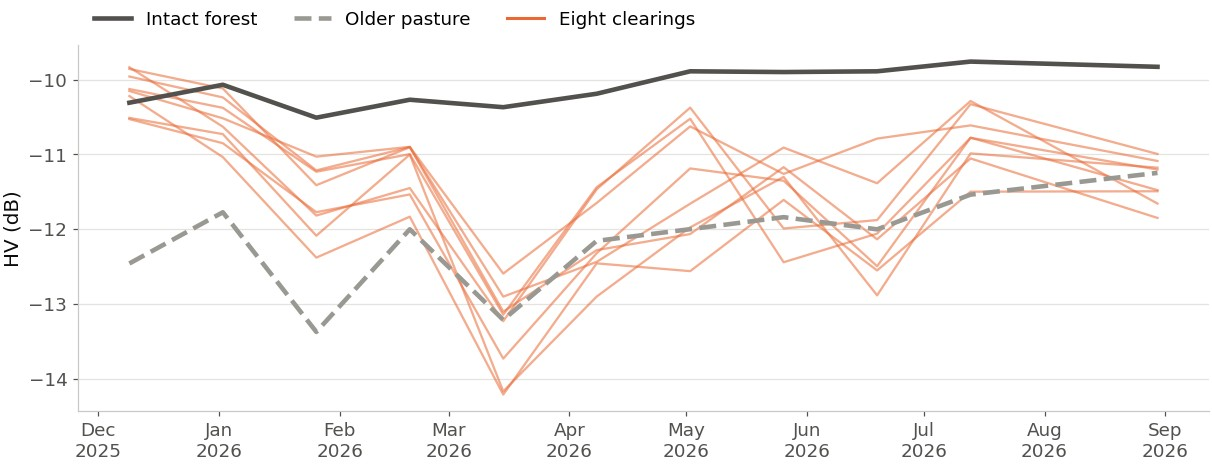

INFO: Case-mean HV step relative to forest: median 1.5 dB (range 1.0 to 1.8)


In [6]:
lin = 10 ** (demo.hv / 10)
hv_forest = 10 * np.log10(dist.reference_series(lin, forest))
pasture = demo.cases_in("pre_series_pasture")
past_mask = np.zeros(demo.shape, bool)
for c in pasture:
    past_mask |= c.mask(demo.shape)
hv_pasture = 10 * np.log10(np.nanmean(lin[:, past_mask], 1))

fig, ax = plt.subplots(figsize=(11, 4.2))
steps = []
for c in clearings:
    series = 10 * np.log10(np.nanmean(lin[:, c.rows, c.cols], 1))
    steps.append(dist.hv_step_dating(series - hv_forest, np.arange(len(series))).step_db)
    ax.plot(demo.hv_dates, series, color=COLORS["HV"], alpha=0.55, lw=1.5)
ax.plot(demo.hv_dates, hv_forest, color=COLORS["forest"], lw=3, label="Intact forest")
ax.plot(demo.hv_dates, hv_pasture, color=COLORS["pasture"], lw=3, ls="--", label="Older pasture")
ax.plot([], [], color=COLORS["HV"], lw=2, label="Eight clearings")
ax.set_ylabel("HV (dB)")
ax.legend(ncol=3, loc="lower left", bbox_to_anchor=(0, 1.0))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
plt.show()
log.info("Case-mean HV step relative to forest: median %.1f dB (range %.1f to %.1f)", np.median(steps), min(steps), max(steps))

## 4. Why raw coherence hides the clearing

Coherence measures how similar two radar images are, from 0 (nothing in common) to 1 (identical). Tropical forest is a hard case: leaves and branches move between passes 12 days apart, so forest coherence is already low. It also varies from pair to pair with rain and wind, and it can never read zero, because coherence estimated from a few pixels is biased upward (`coherence_floor`).

The chart shows the median coherence of intact forest in each pair. The dotted lines are the floors for the 80 m (112 looks) and 20 m (18 looks) products. At 20 m the floor is much closer to forest coherence, leaving less room for a clearing to lower it, and estimates from 18 looks are noisier. Across 1,286 clearing pixels, the pair spanning a clearing separated from normal variation better at 80 m (AUC 0.66) than at 20 m (0.58), so we use the 80 m product for detection.

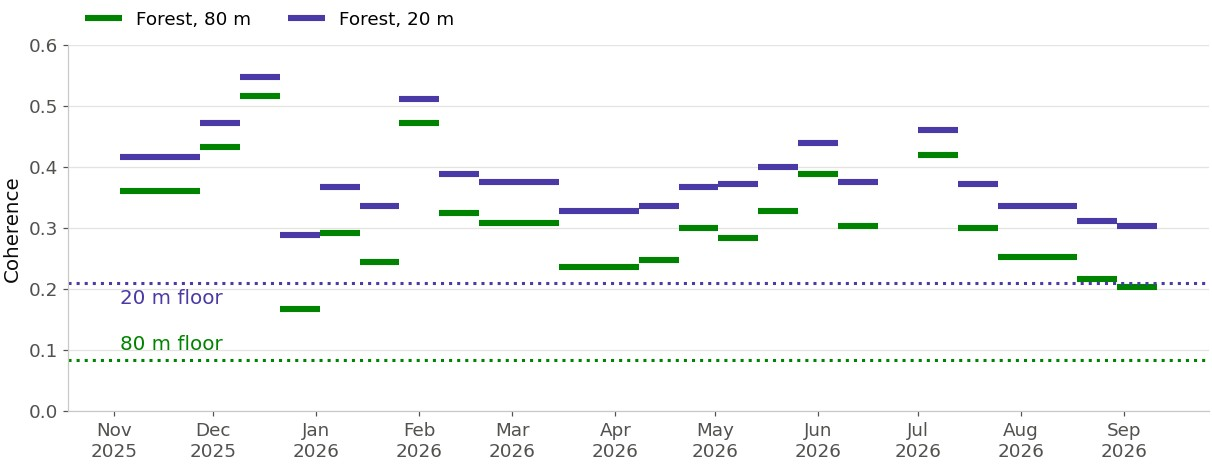

INFO: Lowest forest pair: 21 Dec–2 Jan (80 m forest 0.17 vs floor 0.084)


In [7]:
floor80 = dist.coherence_floor(demo.meta["looks"]["coh80"])
floor20 = dist.coherence_floor(demo.meta["looks"]["coh20"])
scene80 = dist.reference_series(demo.coh80, forest)
scene20 = dist.reference_series(demo.coh20, forest)


def pair_steps(ax, values, **kw):
    """Draw one horizontal segment per pair, spanning its two dates."""
    for i, v in enumerate(values):
        ax.plot([demo.pair_ref[i], demo.pair_sec[i]], [v, v], solid_capstyle="butt", **kw)
        kw.pop("label", None)


fig, ax = plt.subplots(figsize=(11, 4.2))
pair_steps(ax, scene80, color=COLORS["coh80"], lw=4, label="Forest, 80 m")
pair_steps(ax, scene20, color=COLORS["coh20"], lw=4, label="Forest, 20 m")
ax.axhline(floor80, color=COLORS["coh80"], ls=":", lw=2)
ax.axhline(floor20, color=COLORS["coh20"], ls=":", lw=2)
ax.text(demo.pair_ref[0], floor80 + 0.01, "80 m floor", va="bottom", color=COLORS["coh80"])
ax.text(demo.pair_ref[0], floor20 - 0.01, "20 m floor", va="top", color=COLORS["coh20"])
ax.set_ylim(0, 0.6)
ax.set_ylabel("Coherence")
ax.legend(loc="lower left", ncol=2, bbox_to_anchor=(0, 1.0))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
plt.show()
rain = int(np.argmin(scene80))
log.info("Lowest forest pair: %s (80 m forest %.2f vs floor %.3f)", pair_label(rain), scene80[rain], floor80)

Rain is also patchy. The maps below show 80 m coherence in three consecutive pairs. In the first, forest and clearings look much alike. In the second (9–21 Dec), the clearings are black holes in brighter forest. In the third, rain has lowered coherence everywhere, unevenly, and the clearings are hard to see.

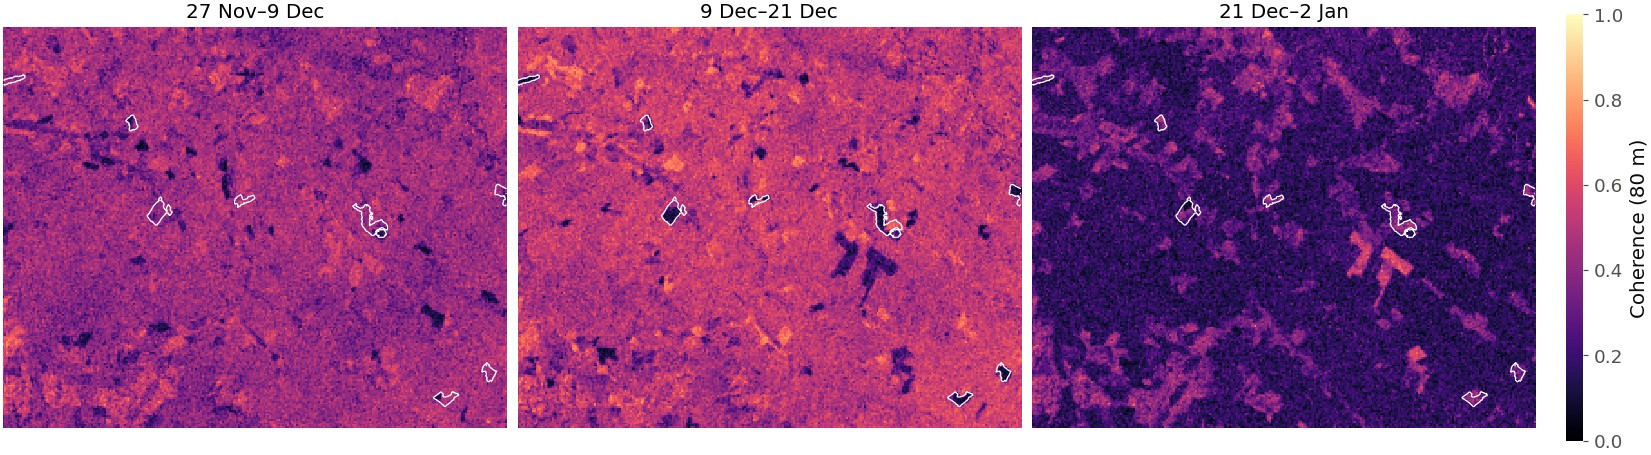

In [8]:
spanning = int(np.flatnonzero(demo.pair_ref == np.datetime64("2025-12-09"))[0])
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
for ax, i in zip(axes, [spanning - 1, spanning, spanning + 1]):
    im = ax.imshow(demo.coh80[i], **CMAPS["coherence"])
    outline(ax, cleared_mask, color="white", lw=0.8)
    image_axes(ax, pair_label(i))
add_colorbar(im, list(axes), "Coherence (80 m)")
plt.show()

## 5. Compare each area with its own history and with nearby forest

Two ideas turn the noisy coherence record into a clear signal.

1. **Weather reference from nearby forest.** Rain falls unevenly, so compare each area with a ring of intact forest 80 to 300 m around it (`forest_ring`), rather than with forest across the whole scene. Subtracting the ring removes most of the weather.
2. **Own history.** Clearing, burning and regrowth each change coherence relative to what the area looked like a few weeks earlier. `own_history_change` compares each pair with the median of the area's three previous pairs.

We then express the change in units of the chance variation of intact forest areas of the same size (`forest_change_noise`). A dip is flagged when it falls below −3 sigma. At that threshold only 4 to 8% of intact forest areas show a false dip anywhere in the 10-month record.

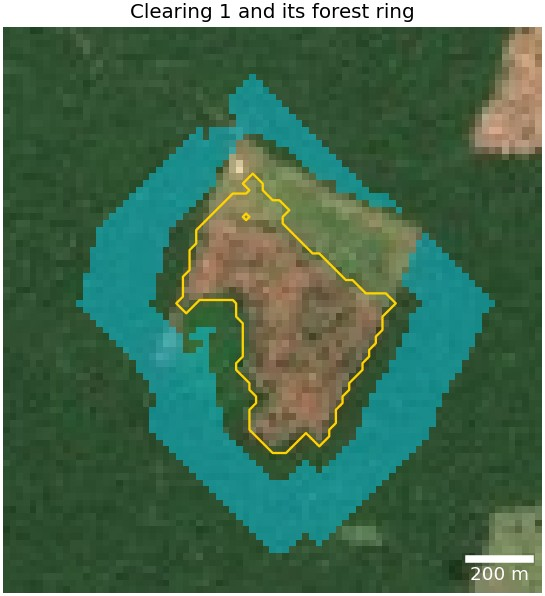

In [9]:
case = demo.cases["forest_clearing_1"]
area = case.mask(demo.shape)
ring = dist.forest_ring(area, demo.radd_forest & np.isnat(demo.radd_alert))
win = case.window(pad=22, shape=demo.shape)

fig, ax = plt.subplots(figsize=(5.4, 5.4))
ax.imshow(rgb_on("2025-12-25")[win])
ring_rgba = np.zeros(ring[win].shape + (4,))
ring_rgba[ring[win]] = (0.0, 0.85, 1.0, 0.45)
ax.imshow(ring_rgba)
outline(ax, area[win])
image_axes(ax, "Clearing 1 and its forest ring")
add_scalebar(ax, PX)
plt.show()

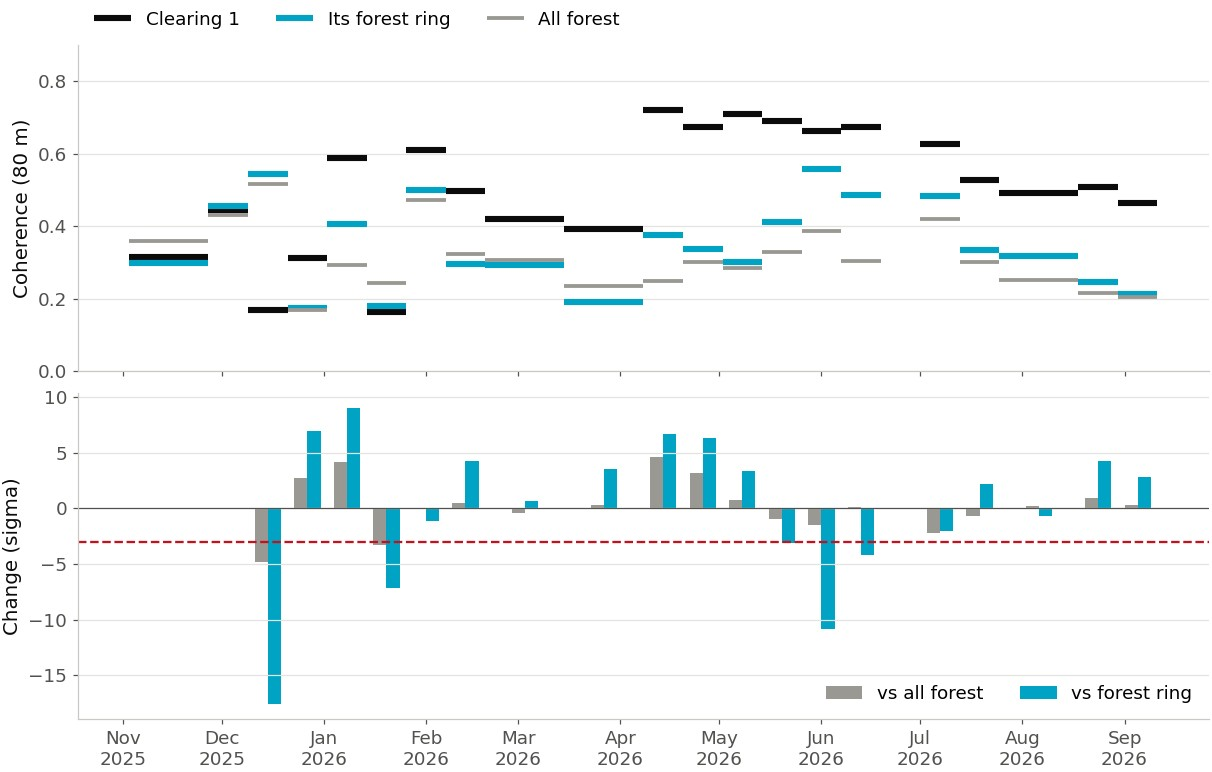

INFO: Deepest dip: 9 Dec–21 Dec, -17.6 sigma vs ring, -4.8 sigma vs all forest


In [10]:
area_series = np.nanmean(demo.coh80[:, area], 1)
ring_series = dist.reference_series(demo.coh80, ring, "mean")
noise_ring = dist.forest_change_noise(demo.coh80, forest, area.sum(), "ring", ring_forest=demo.radd_forest & np.isnat(demo.radd_alert), seed=20260924)
noise_scene = dist.forest_change_noise(demo.coh80, forest, area.sum(), "scene", seed=20260924)
dips_ring = dist.coherence_dips(area_series, ring_series, noise_ring.change_sd, threshold=3.0)
dips_scene = dist.coherence_dips(area_series, scene80, noise_scene.change_sd, threshold=2.5)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True, height_ratios=[1, 1])
pair_steps(ax1, area_series, color=COLORS["ink"], lw=4, label="Clearing 1")
pair_steps(ax1, ring_series, color="#00a3c4", lw=4, label="Its forest ring")
pair_steps(ax1, scene80, color=COLORS["pasture"], lw=2.5, label="All forest")
ax1.set_ylabel("Coherence (80 m)")
ax1.legend(ncol=3, loc="lower left", bbox_to_anchor=(0, 1.0))
ax1.set_ylim(0, 0.9)

x = demo.pair_mid.astype("datetime64[D]")
width = np.timedelta64(4, "D")
ax2.bar(x - width / 2, dips_scene.sigma, width=4, color=COLORS["pasture"], label="vs all forest")
ax2.bar(x + width / 2, dips_ring.sigma, width=4, color="#00a3c4", label="vs forest ring")
ax2.axhline(-3, color=COLORS["detection"], ls="--", lw=1.5)
ax2.axhline(0, color=COLORS["ink2"], lw=0.8)
ax2.set_ylabel("Change (sigma)")
ax2.legend(ncol=2, loc="lower right")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
plt.show()
d = dips_ring.deepest
log.info("Deepest dip: %s, %.1f sigma vs ring, %.1f sigma vs all forest", pair_label(d), dips_ring.sigma[d], dips_scene.sigma[d])

Against all forest the felling pair (9–21 Dec) is a modest dip. Against the forest ring it is a drop of more than 15 sigma, because the ring shares the clearing's weather and its noise is about three times lower.

## 6. One clearing, three sensors

The figure below follows clearing 1 through the season. Optical imagery (top) shows felling between 5 and 25 December. 80 m coherence (bottom) dips in the pair that spans the felling, then rises well above forest once the land is open. HV (middle) drops more gradually as the felled trees dry out and are burned. The framed panels mark the first detection by each sensor.

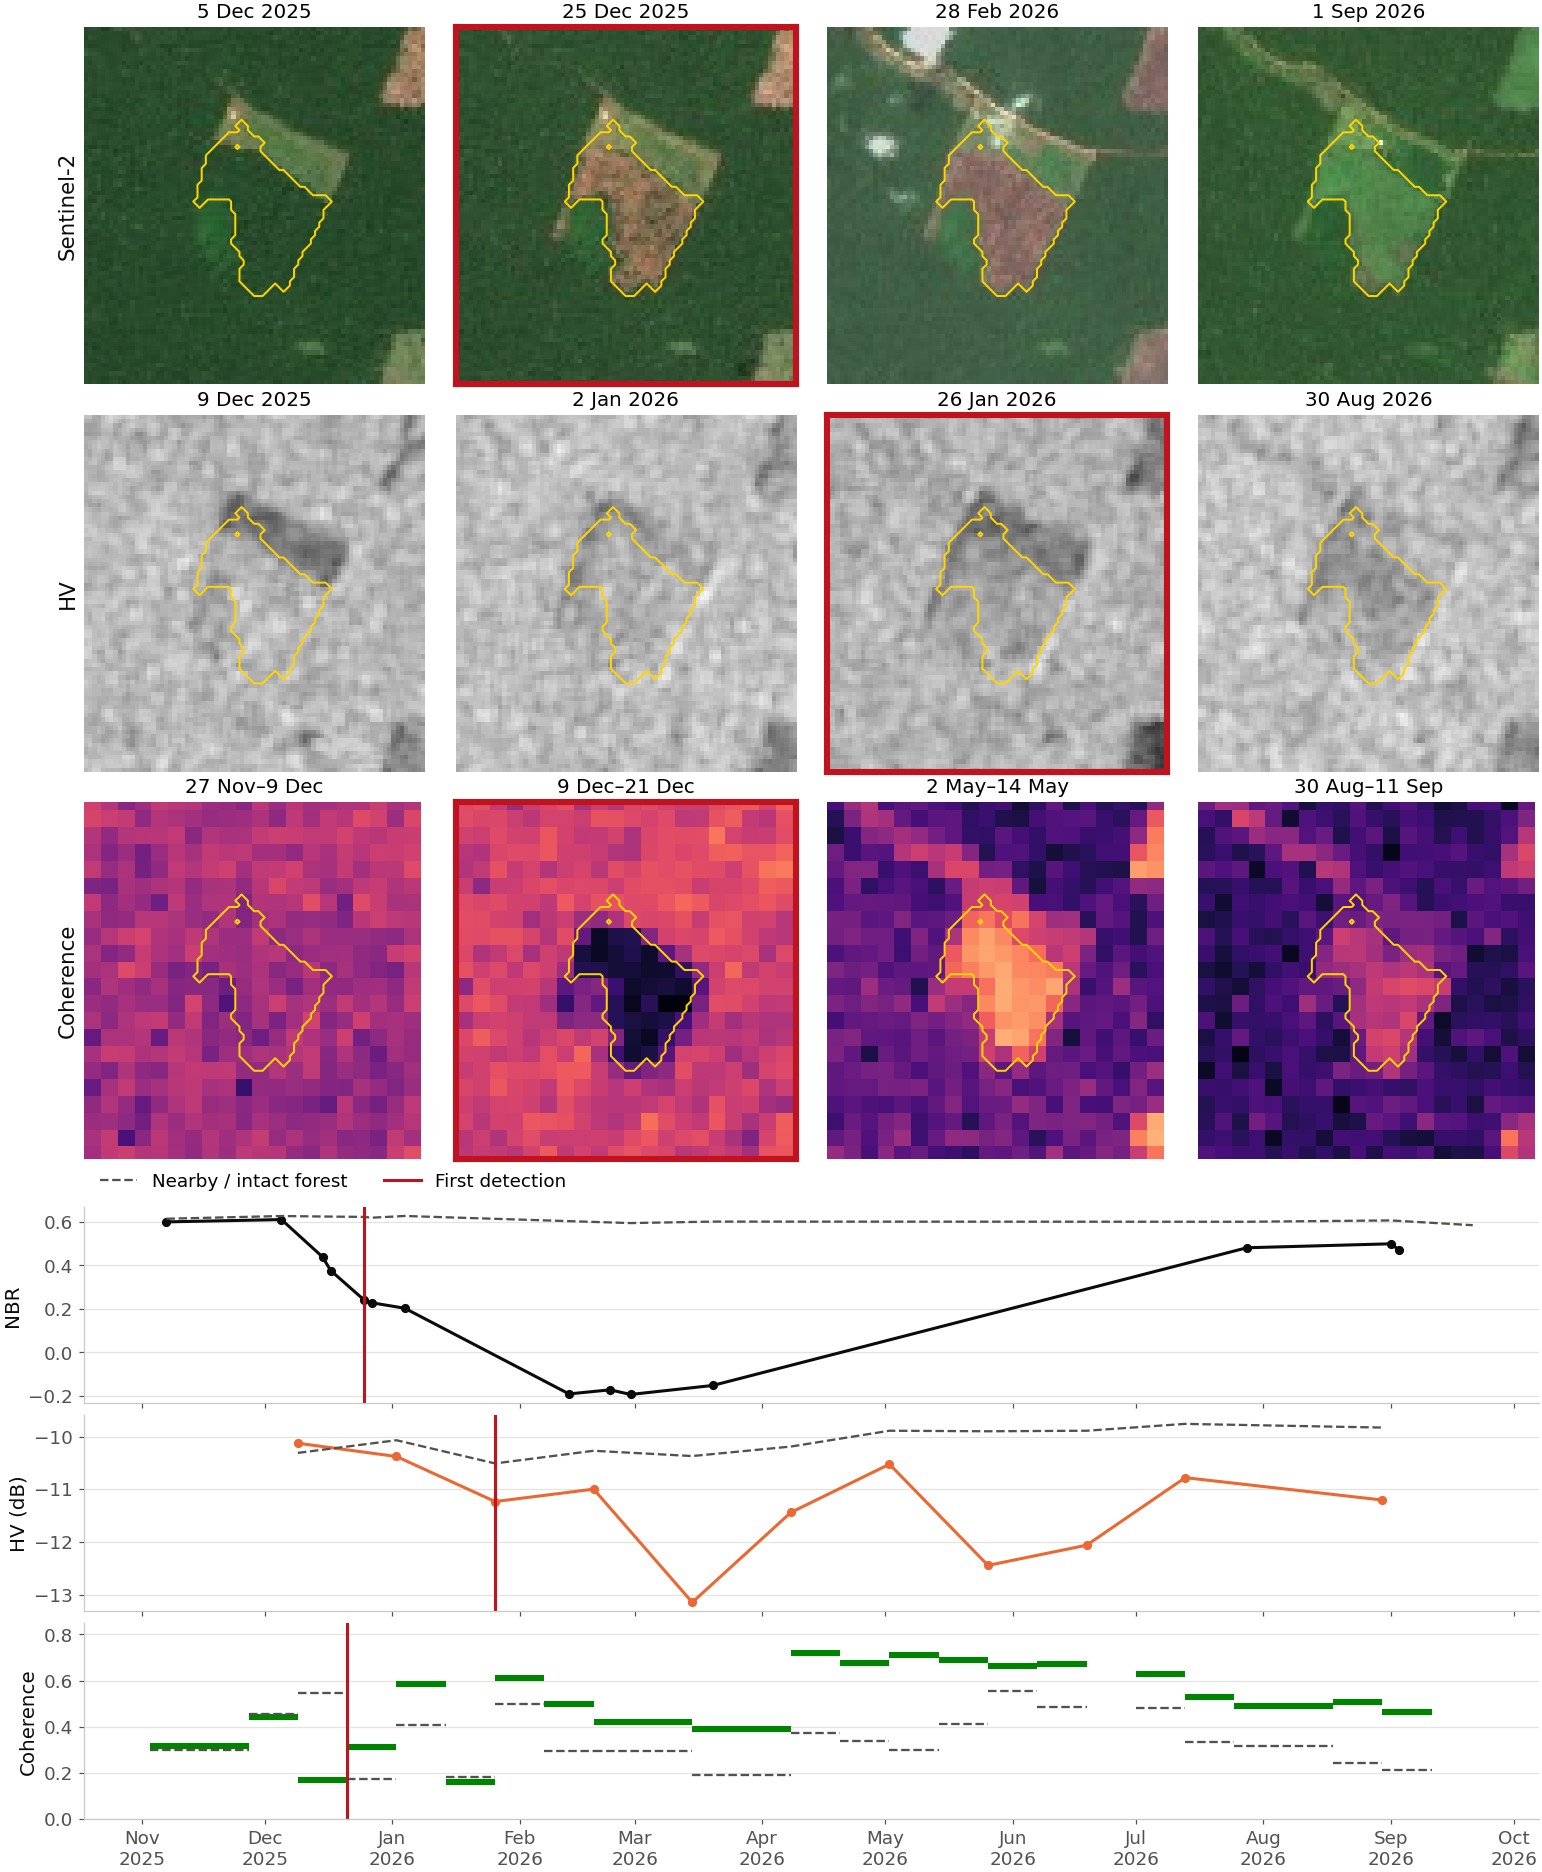

INFO: First detection: NBR 2025-12-25, coherence pair ending 2025-12-21, HV 2026-01-26


In [11]:
hv_case = 10 * np.log10(np.nanmean(lin[:, area], 1)) - hv_forest
hv_step = dist.hv_step_dating(hv_case, np.arange(len(demo.hv_dates)))
hv_after = int(hv_step.index) + 1
first_dip = int(np.flatnonzero(dips_ring.flagged)[0])
nbr_forest = np.interp(case.nbr_dates.astype(float), demo.forest_nbr_dates.astype(float), demo.forest_nbr)
nbr_drop = int(np.flatnonzero(case.nbr < 0.3)[0])
coh_rel = area_series - ring_series
post_pair = spanning + 1 + int(np.nanargmax(np.where(ring_series[spanning + 1 :] >= 0.3, coh_rel[spanning + 1 :], np.nan)))

s2_idx = ["2025-12-05", str(case.nbr_dates[nbr_drop]), "2026-02-28", "2026-09-01"]
hv_idx = [0, hv_after - 1, hv_after, len(demo.hv_dates) - 1]
coh_idx = [spanning - 1, first_dip, post_pair, len(demo.pair_ref) - 1]
first = {0: 1, 1: 2, 2: 1}  # row -> column of each sensor's first detection

fig = plt.figure(figsize=(14, 17))
grid = fig.add_gridspec(6, 4, height_ratios=[1, 1, 1, 0.55, 0.55, 0.55])
fmt = lambda d: np.datetime64(d, "D").astype(object).strftime("%-d %b %Y")  # noqa: E731
rows = [
    ("Sentinel-2", [(rgb_on(d)[win], {}, fmt(d)) for d in s2_idx]),
    ("HV", [(smooth[t][win], CMAPS["hv"], fmt(demo.hv_dates[t])) for t in hv_idx]),
    ("Coherence", [(demo.coh80[p][win], CMAPS["coherence"], pair_label(p)) for p in coh_idx]),
]
for i, (name, panels) in enumerate(rows):
    for j, (img, kw, title) in enumerate(panels):
        ax = fig.add_subplot(grid[i, j])
        ax.imshow(img, **kw)
        outline(ax, area[win], lw=1.3)
        image_axes(ax, title)
        if j == first[i]:
            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_edgecolor(COLORS["detection"])
                spine.set_linewidth(4)
        if j == 0:
            ax.set_ylabel(name, fontsize=14)

ax_nbr = fig.add_subplot(grid[3, :])
ax_hv = fig.add_subplot(grid[4, :], sharex=ax_nbr)
ax_coh = fig.add_subplot(grid[5, :], sharex=ax_nbr)
ax_nbr.plot(case.nbr_dates, case.nbr, "o-", color=COLORS["ink"], ms=5)
ax_nbr.plot(demo.forest_nbr_dates, demo.forest_nbr, color=COLORS["forest"], ls="--", lw=1.5)
ax_nbr.axvline(case.nbr_dates[nbr_drop], color=COLORS["detection"], lw=2)
ax_nbr.set_ylabel("NBR")
ax_hv.plot(demo.hv_dates, hv_case + hv_forest, "o-", color=COLORS["HV"], ms=5)
ax_hv.plot(demo.hv_dates, hv_forest, color=COLORS["forest"], ls="--", lw=1.5)
ax_hv.axvline(demo.hv_dates[hv_after], color=COLORS["detection"], lw=2)
ax_hv.set_ylabel("HV (dB)")
pair_steps(ax_coh, area_series, color=COLORS["coh80"], lw=4)
pair_steps(ax_coh, ring_series, color=COLORS["forest"], lw=1.5, ls="--")
ax_coh.axvline(demo.pair_sec[first_dip], color=COLORS["detection"], lw=2)
ax_coh.set_ylabel("Coherence")
ax_coh.set_ylim(0, 0.85)
for ax in (ax_nbr, ax_hv):
    plt.setp(ax.get_xticklabels(), visible=False)
ax_coh.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
ax_nbr.plot([], [], color=COLORS["forest"], ls="--", lw=1.5, label="Nearby / intact forest")
ax_nbr.plot([], [], color=COLORS["detection"], lw=2, label="First detection")
ax_nbr.legend(ncol=2, loc="lower left", bbox_to_anchor=(0, 1.0))
plt.show()
log.info("First detection: NBR %s, coherence pair ending %s, HV %s", case.nbr_dates[nbr_drop], demo.pair_sec[first_dip], demo.hv_dates[hv_after])

## 7. The whole scene: dips at felling, rises afterwards

The same ideas work pixel by pixel. For each 80 m cell we subtract the mean coherence of intact forest in an 820 m moving window (a pixel-by-pixel version of the forest ring), then compare each pair with the cell's own previous pairs. Only land that was forest in November 2025 is shown; older clearings are grey. The left map shows the change in the pair spanning most of the December felling. The right map shows how far coherence rose above forest over the following months: open land stays coherent between passes, forest does not. About 70% of the strongly rising cells fall inside RADD alerts from this period; about 15% sit within 100 m of an older clearing, where an 80 m cell mixes forest and pasture.

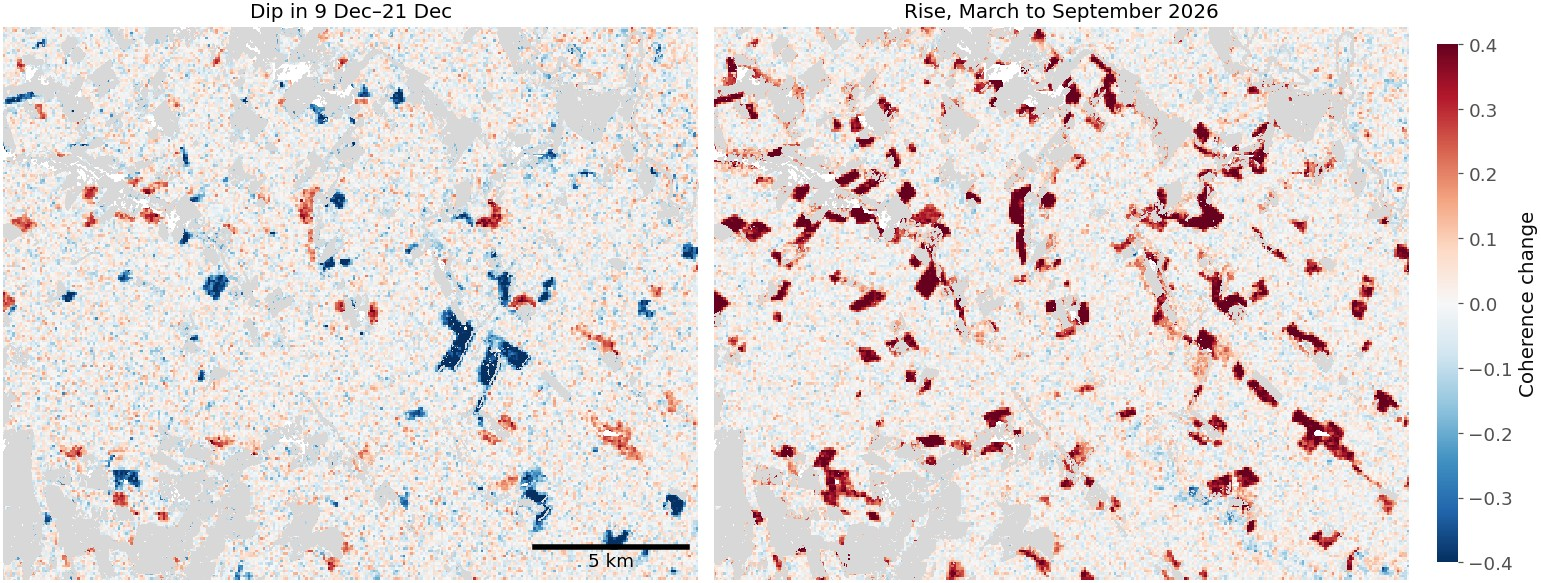

INFO: Cells rising > 0.2: 72% in RADD alerts from this period, 15% within 100 m of an older clearing


In [12]:
def local_forest_mean(img: np.ndarray, mask: np.ndarray, size: int = 41) -> np.ndarray:
    """Mean of forest pixels in a moving window."""
    w = (mask & np.isfinite(img)).astype(float)
    num = ndimage.uniform_filter(np.where(w > 0, img, 0.0), size)
    den = ndimage.uniform_filter(w, size)
    return np.where(den > 0.01, num / np.maximum(den, 1e-9), np.nan)


forest_at_start = demo.radd_forest & ~(demo.radd_alert < demo.pair_ref[0])
delta = np.stack([demo.coh80[p] - local_forest_mean(demo.coh80[p], forest) for p in range(len(demo.pair_ref))])
delta[:, ~forest_at_start] = np.nan  # only land that was forest in November 2025
baseline = np.nanmedian(delta[max(spanning - 3, 0) : spanning], 0)
dip_map = delta[spanning] - baseline
post = (demo.pair_ref >= np.datetime64("2026-03-01")) & (scene80 >= 0.30)
rise_map = np.nanmedian(delta[post], 0) - baseline

fig, axes = plt.subplots(1, 2, figsize=(14, 5.6))
for ax, img, title in zip(axes, [dip_map, rise_map], [f"Dip in {pair_label(spanning)}", "Rise, March to September 2026"]):
    ax.imshow(np.where(forest_at_start, np.nan, 1.0), cmap="Greys", vmin=0, vmax=4)
    im = ax.imshow(img, cmap="RdBu_r", vmin=-0.4, vmax=0.4)
    image_axes(ax, title)
add_scalebar(axes[0], PX, color="black")
add_colorbar(im, list(axes), "Coherence change")
plt.show()

alerted = demo.radd_alert >= demo.pair_ref[0]
near_edge = ndimage.distance_transform_edt(forest_at_start) * PX < 100
strong = rise_map > 0.2
log.info("Cells rising > 0.2: %.0f%% in RADD alerts from this period, %.0f%% within 100 m of an older clearing", 100 * (strong & alerted).sum() / strong.sum(), 100 * (strong & ~alerted & near_edge).sum() / strong.sum())

## 8. How reliable is this?

Each dot is one area: eight forest clearings, eight squares of intact forest and eight squares of older pasture, all measured against their own forest rings. Clearings fall 13 to 18 sigma below their history. Intact forest stays at or above the −3 sigma line. Pasture is the caveat: burning or ploughing already-open land also lowers coherence, and five of the eight pasture squares cross the forest-calibrated threshold at least once. Non-forest land needs its own calibration.

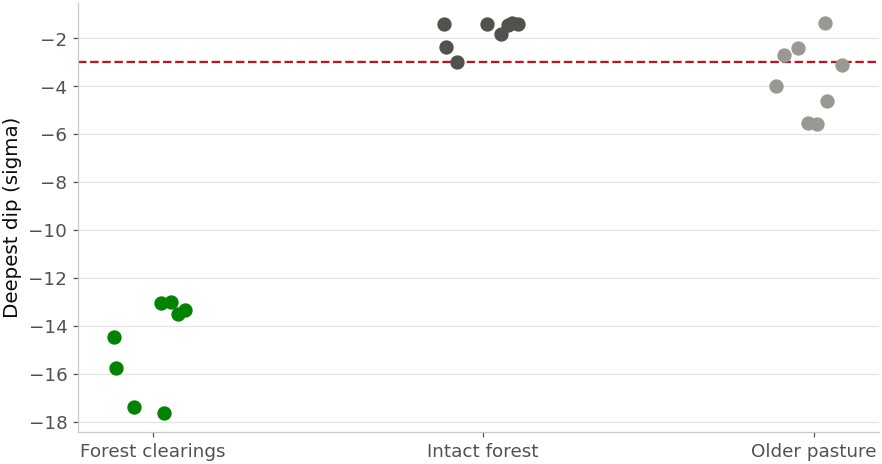

In [13]:
groups = {
    "Forest clearings": "forest_clearing",
    "Intact forest": "stable_forest",
    "Older pasture": "pre_series_pasture",
}
fig, ax = plt.subplots(figsize=(8, 4.2))
rng = np.random.default_rng(0)
for k, (label, cat) in enumerate(groups.items()):
    vals = [float(c.attrs["deepest_sigma"]) for c in demo.cases_in(cat)]
    ax.scatter(np.full(len(vals), k) + rng.uniform(-0.12, 0.12, len(vals)), vals, s=70, color=[COLORS["coh80"], COLORS["forest"], COLORS["pasture"]][k], zorder=3)
ax.axhline(-3, color=COLORS["detection"], ls="--", lw=1.5)
ax.set_xticks(range(len(groups)), list(groups))
ax.set_ylabel("Deepest dip (sigma)")
plt.show()

Two more limits are worth keeping in mind:

- **Masked pairs.** When rain has already pushed forest coherence close to the floor (the 21 Dec to 2 Jan pair reads about 0.17 in forest), a clearing cannot lower it further. `coherence_dips` flags pairs whose reference forest is below 0.30 as masked rather than testing them.
- **Timing.** Aligned on their RADD alert dates, clearing pixels start to lose HV about 50 days before the alert, and in clearing 1 the coherence dip came five weeks before the HV detection. NISAR may therefore date clearings earlier than current alert systems, but confirming this needs a larger sample.

## 9. Experimental: a forward-running Disturbance Index

A detection system has to work without outlines. `disturbance_index` processes images in date order. Each image is standardized against the current forest (after removing each pixel's own mean), a pixel is flagged after two exceedances in a row, and detected pixels leave the forest. Here we look for a sustained **rise** in 80 m coherence, the strongest single-layer signal so far.

> **Work in progress.** In a first validation against 128 reference clearings, this detector caught 26% of them on time. Treat the map as exploratory.

All land that was forest in November 2025 is monitored, so the detector gets no help from the outlines.

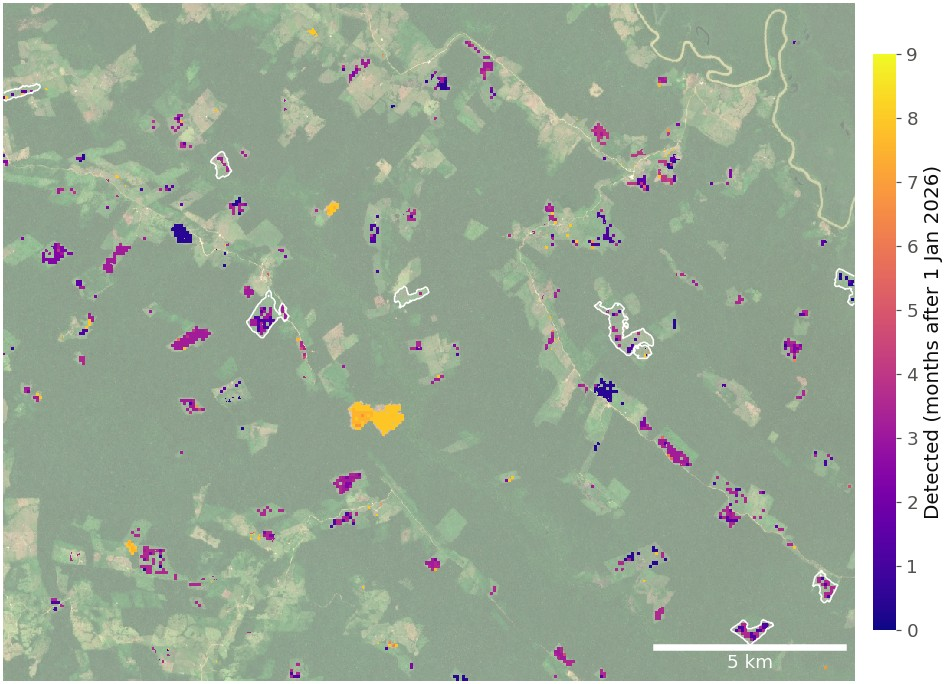

INFO: Flagged 780 ha: 28% of the eight clearings, 19% of high-confidence RADD alerts since November, 0.3% of stable forest


In [14]:
start = int(np.flatnonzero(demo.pair_ref >= np.datetime64("2026-01-01"))[0])
forest_at_start = demo.radd_forest & ~(demo.radd_alert < demo.pair_ref[0])  # forest in November 2025
di = dist.disturbance_index(demo.coh80, forest_at_start, start=start, method="pixmean", threshold=3.0, n_consecutive=2, sign=1)
det = di.detection_date(demo.pair_sec.astype("datetime64[D]").astype(float))
months = (det - np.datetime64("2026-01-01").astype(float)) / 30.44

fig, ax = plt.subplots(figsize=(9, 6.2))
ax.imshow(rgb_on("2026-09-01"), alpha=0.55)
im = ax.imshow(np.where(np.isfinite(months), months, np.nan), cmap="plasma", vmin=0, vmax=9)
outline(ax, cleared_mask, color="white", lw=1)
image_axes(ax)
add_scalebar(ax, PX)
cb = add_colorbar(im, ax, "Detected (months after 1 Jan 2026)")
plt.show()
new_alerts = forest_at_start & (demo.radd_alert >= demo.pair_ref[0]) & (demo.radd_conf == 3)
log.info("Flagged %.0f ha: %.0f%% of the eight clearings, %.0f%% of high-confidence RADD alerts since November, %.1f%% of stable forest", di.detected.sum() * PX**2 / 1e4, 100 * di.detected[cleared_mask].mean(), 100 * di.detected[new_alerts].mean(), 100 * di.detected[forest].mean())

The detector flags about a quarter of the eight clearings and about a fifth of the high-confidence RADD alerts since November, while flagging well under 1% of stable forest. It finds cleared patches outside the outlines, and some large patches only months later (orange), when coherence stays high through the dry season. A dip detector and local weather references, as in section 5, are the obvious next steps.

## 10. Stream the data yourself

The bundle was cut from full NISAR frames. With a free [NASA Earthdata](https://urs.earthdata.nasa.gov/) account you can stream any window from the same granules. `granule_url` builds the archive URL from a granule ID, and `subset_product` reads only the pixels inside the bounding box over HTTPS (about 10 to 30 s per layer).

```python
from nice_sar.auth import get_https_filesystem, login
from nice_sar.datasets import CAQUETA_AOI
from nice_sar.io.subset import subset_product
from nice_sar.search import granule_url

login()
fs = get_https_filesystem()
gid = demo.meta["granules"][0]
subset_product(granule_url(gid), product="GCOV", bbox=CAQUETA_AOI, polarizations=["HV"],
               output_dir="caqueta", filesystem=fs, confirm=False)
```

## Summary

- HV backscatter falls 1 to 2 dB when forest becomes pasture, dated by `hv_step_dating`.
- Coherence dips when trees are felled and rises once the land is open.
- Comparing each area with its own history and with nearby forest (`forest_ring`, `own_history_change`, `coherence_dips`) turns a noisy signal into dips of 13 to 18 sigma.
- Rain can mask a pair, and non-forest land needs its own calibration.

The full analysis, with case studies in six categories and the calibration of every threshold, is in [`scripts/caqueta/`](https://github.com/bullocke/nice-sar/tree/main/scripts/caqueta). Previous tutorial: [10 · Texture](10_texture_comparison.ipynb).

In [15]:
import nice_sar

log.info("nice-sar %s, run on %s", nice_sar.__version__, np.datetime64("today"))

INFO: nice-sar 0.2.0, run on 2026-09-25
